# Phase 4 — QB Model: Tuned XGBoost with Walk-Forward Optuna Search

Trained only on QB's Phase 3-selected 6 features: `scarcity_z`, `draft_pick_inverse`, `vorp_delta_yoy`, `passing_epa`, `age`, `ol_pass_protection_proxy`. This is the first of Phase 4's real hyperparameter-tuning notebooks — testing whether tuning meaningfully closes the gap Phase 3's untuned model left against the naive baseline (6.0% MAE, +0.029 Spearman).

In [1]:
from datetime import datetime

print(f"Results as of {datetime.now().astimezone():%Y-%m-%d %H:%M %Z}, pulling live nflreadpy data -- "
      "rerunning this notebook will reflect any upstream corrections made to that data since.")

Results as of 2026-09-16 13:46 Central Daylight Time, pulling live nflreadpy data -- rerunning this notebook will reflect any upstream corrections made to that data since.


## Setup: load `features_df` and build QB's target rows

Only the 6 already-selected features are built here — not the full Phase 3 pipeline. QB's feature set doesn't include `ol_run_blocking_proxy`, so the expensive 18-season play-by-play pull from Phase 3 isn't needed at all for this notebook.

In [2]:
import sys
from pathlib import Path

import nflreadpy as nfl
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "draft_pick_inverse", "vorp_delta_yoy", "passing_epa", "age", "ol_pass_protection_proxy"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
qb = vorp_labels[vorp_labels["position"] == "QB"][
    ["season", "player_id", "player_display_name", "recent_team", "vorp", "vorp_next", "passing_epa"]
].copy()

# scarcity_z (within-position, within-season standardization -- same recipe as Phase 3)
season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
qb_stats = season_position_stats[season_position_stats["position"] == "QB"]
qb = qb.merge(qb_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
qb["scarcity_z"] = (qb["vorp"] - qb["position_mean_vorp"]) / qb["position_std_vorp_that_season"]
qb = qb.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

# vorp_delta_yoy
prior = qb[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
qb = qb.merge(prior, on=["player_id", "season"], how="left")
qb["vorp_delta_yoy"] = qb["vorp"] - qb["vorp_last_season"]
qb = qb.drop(columns=["vorp_last_season"])

# age, draft_pick_inverse
players = nfl.load_players().to_pandas()
qb = qb.merge(players[["gsis_id", "birth_date", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
qb["birth_date"] = pd.to_datetime(qb["birth_date"])
season_start = pd.to_datetime(qb["season"].astype(str) + "-09-01")
qb["age"] = (season_start - qb["birth_date"]).dt.days / 365.25
qb["draft_pick_inverse"] = 1 / qb["draft_pick"]
qb = qb.drop(columns=["gsis_id", "birth_date", "draft_pick"])

# ol_pass_protection_proxy (team-season sack rate allowed)
team_stats = nfl.load_team_stats(seasons=True, summary_level="reg").to_pandas()
team_stats = team_stats[(team_stats["season"] >= 2008) & (team_stats["season"] <= 2025)].copy()
team_stats["ol_pass_protection_proxy"] = team_stats["sacks_suffered"] / (team_stats["attempts"] + team_stats["sacks_suffered"])
qb = qb.merge(
    team_stats[["season", "team", "ol_pass_protection_proxy"]],
    left_on=["season", "recent_team"], right_on=["season", "team"], how="left",
)
qb = qb.drop(columns=["team", "recent_team"])

# Keep 2025's rows before dropping them below -- their vorp_next is 2026's outcome, which
# doesn't exist yet, so dropna() would discard them. Needed later for the live 2026 inference section.
qb_2025_features = qb[qb["season"] == 2025].copy()

qb = qb.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"QB rows with a usable label: {len(qb)}, seasons {qb['season'].min()}-{qb['season'].max()}")
print(qb[FEATURES].isna().mean().rename("null_rate"))

C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QB rows with a usable label: 980, seasons 2008-2024
scarcity_z                  0.000000
draft_pick_inverse          0.133673
vorp_delta_yoy              0.253061
passing_epa                 0.025510
age                         0.000000
ol_pass_protection_proxy    0.000000
Name: null_rate, dtype: float64


## Walk-forward folds (same structure as `05_feature_selection.ipynb`)

In [3]:
MIN_TRAIN_SEASONS = 9


def make_walk_forward_folds(df, min_train_seasons=MIN_TRAIN_SEASONS):
    seasons_sorted = sorted(df["season"].unique())
    folds = []
    for i in range(min_train_seasons, len(seasons_sorted)):
        train_seasons = sorted(seasons_sorted[:i])
        test_season = seasons_sorted[i]
        train_idx = df.index[df["season"].isin(train_seasons)].to_numpy()
        test_idx = df.index[df["season"] == test_season].to_numpy()
        if len(train_idx) > 0 and len(test_idx) > 0:
            folds.append((train_idx, test_idx, test_season, train_seasons))
    return folds


folds = make_walk_forward_folds(qb)
print(f"{len(folds)} walk-forward folds, test seasons: {[f[2] for f in folds]}")

8 walk-forward folds, test seasons: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Monotonic constraints: checked per feature, not assumed

Each of QB's 6 features checked individually for whether it has an unambiguous, confound-free "more is better/worse" relationship with next-season value:

| Feature | Constraint | Reasoning |
|---|---|---|
| `scarcity_z` | **+1** | Standing further above the field *this* season should never predict a *worse* expected standing next season, all else equal. Unambiguous. |
| `vorp_delta_yoy` | **+1** | An improving trajectory is more plausible to continue than to reverse, especially once `scarcity_z` already anchors the current level. |
| `passing_epa` | **+1** | A direct, designed-for-this efficiency metric — no realistic mechanism where being *more* efficient this season predicts *lower* value next season, holding the other features fixed. |
| `age` | **0 (none)** | Explicitly NOT monotonic — fantasy production peaks then declines with age; forcing a single direction here would contradict the real shape of the curve. |
| `draft_pick_inverse` | **0 (none)** | Real ambiguity: this is a fixed pre-career proxy for opportunity/organizational investment, not a performance metric. Conditional on the other 5 features (especially realized performance via `scarcity_z`/`passing_epa`), it's not clean enough to force a direction — it could just as easily be picking up sunk-cost bias (teams keep playing bad high picks) as true signal. Left unconstrained rather than guessed. |
| `ol_pass_protection_proxy` | **0 (none)** | Already documented as a confounded proxy in Phase 3 (reflects QB pocket presence and scheme, not just the line) — a QB who takes more sacks by design (extending plays, mobile style) isn't necessarily worse off. Too ambiguous to force a direction. |

**3 of 6 features get a constraint** (`scarcity_z`, `vorp_delta_yoy`, `passing_epa`, all `+1`); the other 3 are left free. This is deliberately conservative — a wrong constraint forces the model into an incorrect shape, which is worse than no constraint at all.

In [4]:
MONOTONE_CONSTRAINTS = (1, 0, 1, 1, 0, 0)  # matches FEATURES order exactly
print(dict(zip(FEATURES, MONOTONE_CONSTRAINTS)))

{'scarcity_z': 1, 'draft_pick_inverse': 0, 'vorp_delta_yoy': 1, 'passing_epa': 1, 'age': 0, 'ol_pass_protection_proxy': 0}


## Per-fold Optuna search (TPE sampler, pruning enabled)

For each outer walk-forward fold, the search space is `max_depth` (2-8), `min_child_weight` (1-10), `reg_lambda` (log-scale 0.1-10), `learning_rate` (log-scale 0.01-0.3), `subsample` (0.6-1.0). `n_estimators` is never tuned directly — each trial uses early stopping (up to 500 rounds, 20-round patience) to find its own iteration count.

`max_depth`'s range was widened from an earlier 2-4 band to 2-8 after `05b_qb_feature_experiment.ipynb` confirmed the shallow-tree cap was artificial (not XGBoost's own default of 6) and that roughly half of these real folds, once given the room, preferred something deeper than 2 — this notebook now gives Optuna that same room rather than assuming the narrow band.

**The search never touches the outer fold's held-out test season.** Within each outer fold's own training window, the *most recent* training season is carved out as an inner validation split (everything before it is inner-train) — Optuna's objective is scored purely on that inner split. Real mid-training pruning is wired in via a custom `xgboost.callback.TrainingCallback` that reports each boosting round's validation MAE back to Optuna's `MedianPruner`, not just a pass/fail after the fact.

Once a fold's best hyperparameters and iteration count are found (from the inner split alone), the model is refit on the *entire* outer-fold training window before being scored on the real, still-untouched held-out test season.

**Interface note**: this uses `XGBRegressor.fit(X, y, eval_set=[...])` (the sklearn-compatible wrapper), not `xgb.train()`/`DMatrix` (the native API). The two are numerically identical — same underlying booster, same params, same seed — this is purely an interface choice. One consequence: `XGBRegressor`'s eval sets are auto-named `validation_0`, `validation_1`, ... rather than the caller-chosen names `xgb.train(evals=[...])` allows, so the pruning callback reads `evals_log["validation_0"]` instead of a custom `"valid"` key.

In [5]:
N_TRIALS = 40


class OptunaPruningCallback(xgb.callback.TrainingCallback):
    """Reports each boosting round's validation MAE back to Optuna so its
    pruner can stop a clearly-unpromising trial mid-training, not just
    compare finished trials against each other after the fact.

    Reads "validation_0" -- XGBRegressor's auto-generated eval_set name --
    not the "valid" key the native xgb.train(evals=[...]) API would use."""

    def __init__(self, trial):
        self.trial = trial

    def after_iteration(self, model, epoch, evals_log):
        score = evals_log["validation_0"]["mae"][-1]
        self.trial.report(score, step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned()
        return False


def run_optuna_for_fold(df, train_idx, monotone_constraints, n_trials=N_TRIALS, seed=42):
    train_seasons_sorted = sorted(df.loc[train_idx, "season"].unique())
    inner_valid_season = train_seasons_sorted[-1]
    inner_train_seasons = train_seasons_sorted[:-1]
    inner_train_idx = df.index[df["season"].isin(inner_train_seasons) & df.index.isin(train_idx)]
    inner_valid_idx = df.index[(df["season"] == inner_valid_season) & df.index.isin(train_idx)]

    X_train = df.loc[inner_train_idx, FEATURES]
    y_train = df.loc[inner_train_idx, "vorp_next"]
    X_valid = df.loc[inner_valid_idx, FEATURES]
    y_valid = df.loc[inner_valid_idx, "vorp_next"]

    def objective(trial):
        params = {
            "objective": "reg:squarederror", "eval_metric": "mae",
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10, log=True),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "monotone_constraints": monotone_constraints, "seed": seed,
            "n_estimators": 500, "early_stopping_rounds": 20,
            "callbacks": [OptunaPruningCallback(trial)],
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        trial.set_user_attr("best_iteration", model.best_iteration)
        return model.best_score

    study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study


def fold_gain_share(model):
    """Gain importance for one fold's refit booster, normalized to shares
    over FEATURES (0 for any feature the booster never split on) -- same
    definition Phase 3 used (mean gain share across walk-forward folds)."""
    scores = model.get_booster().get_score(importance_type="gain")
    raw = np.array([scores.get(f, 0.0) for f in FEATURES])
    total = raw.sum()
    return raw / total if total > 0 else raw


def run_all_folds(df, folds, monotone_constraints, label):
    fold_results, fold_best_params, fold_gain_shares, oof_rows = [], [], [], []
    for tr, te, test_season, train_seasons in folds:
        study = run_optuna_for_fold(df, tr, monotone_constraints)
        best_params = dict(study.best_params)
        best_iteration = study.best_trial.user_attrs["best_iteration"]

        X_train_full = df.loc[tr, FEATURES]
        y_train_full = df.loc[tr, "vorp_next"]
        X_test = df.loc[te, FEATURES]
        final_model = xgb.XGBRegressor(
            objective="reg:squarederror", monotone_constraints=monotone_constraints, seed=42,
            n_estimators=max(best_iteration, 1), **best_params,
        )
        final_model.fit(X_train_full, y_train_full)
        preds = final_model.predict(X_test)
        actual = df.loc[te, "vorp_next"]

        mae = mean_absolute_error(actual, preds)
        rmse = mean_squared_error(actual, preds) ** 0.5
        rho = spearmanr(actual, preds)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan

        fold_results.append({"position": "QB", "test_season": test_season, "n_test": len(te), "mae": mae, "rmse": rmse, "spearman": rho})
        fold_best_params.append(best_params | {"n_estimators": best_iteration})
        fold_gain_shares.append(fold_gain_share(final_model))
        oof_rows.append(pd.DataFrame({
            "test_season": test_season,
            "predicted_vorp_next": preds,
            "actual_vorp_next": actual.to_numpy(),
            "vorp_delta_yoy": df.loc[te, "vorp_delta_yoy"].to_numpy(),
            "scarcity_z": df.loc[te, "scarcity_z"].to_numpy(),
        }))

    fold_df = pd.DataFrame(fold_results)
    mean_gain_df = pd.DataFrame({"feature": FEATURES, "mean_gain_share": np.mean(fold_gain_shares, axis=0)})
    oof_df = pd.concat(oof_rows, ignore_index=True)
    print(f"[{label}] Mean MAE: {fold_df['mae'].mean():.2f}, Mean RMSE: {fold_df['rmse'].mean():.2f}, Mean Spearman: {fold_df['spearman'].mean():.3f}")
    return fold_df, pd.DataFrame(fold_best_params), mean_gain_df, oof_df


fold_metrics_df, fold_params_df, gain_constrained_df, oof_constrained_df = run_all_folds(qb, folds, MONOTONE_CONSTRAINTS, label="tuned + monotonic")
print(fold_metrics_df.to_string(index=False))

[tuned + monotonic] Mean MAE: 71.68, Mean RMSE: 93.07, Mean Spearman: 0.670
position  test_season  n_test       mae      rmse  spearman
      QB         2017      51 76.561865 97.559872  0.708911
      QB         2018      50 74.045028 99.491135  0.611011
      QB         2019      57 75.853815 97.777956  0.688424
      QB         2020      61 68.498352 89.452022  0.697832
      QB         2021      67 60.419531 78.096889  0.749062
      QB         2022      63 76.443178 97.291124  0.598812
      QB         2023      63 72.786283 93.713348  0.653770
      QB         2024      63 68.821538 91.171336  0.654146


## Diagnostic: does the monotonic constraint actually help?

Domain reasoning alone doesn't guarantee a constraint helps a small dataset — checked directly rather than assumed, the same way every other claim in this project has been.

In [6]:
NO_CONSTRAINTS = (0, 0, 0, 0, 0, 0)
fold_metrics_unconstrained_df, fold_params_unconstrained_df, gain_unconstrained_df, oof_unconstrained_df = run_all_folds(qb, folds, NO_CONSTRAINTS, label="tuned, no constraints")

[tuned, no constraints] Mean MAE: 67.72, Mean RMSE: 88.50, Mean Spearman: 0.700


### `draft_pick_inverse` vs `passing_epa`: actual gain values, not just rank

Both gain-importance runs above use the **same methodology as Phase 3** (mean gain share across the walk-forward folds' own refit models, not a single all-data model), so this is a genuine apples-to-apples comparison, not a different metric being confused for the same one.

In [7]:
# Phase 3's original untuned mean gain shares (05_feature_selection.ipynb), for the same 2 features.
phase3_gain = {"draft_pick_inverse": 0.089759, "passing_epa": 0.048958}

focus = ["draft_pick_inverse", "passing_epa"]
rows = []
for f in focus:
    constrained_val = gain_constrained_df.set_index("feature").loc[f, "mean_gain_share"]
    unconstrained_val = gain_unconstrained_df.set_index("feature").loc[f, "mean_gain_share"]
    rows.append({
        "feature": f,
        "phase3_untuned": phase3_gain[f],
        "phase4_tuned_constrained": constrained_val,
        "phase4_tuned_unconstrained": unconstrained_val,
    })
focus_df = pd.DataFrame(rows)
print(focus_df.to_string(index=False))

print("\nGap (draft_pick_inverse - passing_epa), each run:")
for col in ["phase3_untuned", "phase4_tuned_constrained", "phase4_tuned_unconstrained"]:
    gap = focus_df.set_index("feature").loc["draft_pick_inverse", col] - focus_df.set_index("feature").loc["passing_epa", col]
    ratio = focus_df.set_index("feature").loc["draft_pick_inverse", col] / focus_df.set_index("feature").loc["passing_epa", col]
    print(f"  {col}: gap={gap:+.4f}, draft_pick_inverse is {ratio:.2f}x passing_epa")

print("\nFull gain tables (all 6 features), for context:")
print("\nConstrained (Phase 4 official):")
print(gain_constrained_df.sort_values('mean_gain_share', ascending=False).to_string(index=False))
print("\nUnconstrained (diagnostic):")
print(gain_unconstrained_df.sort_values('mean_gain_share', ascending=False).to_string(index=False))

           feature  phase3_untuned  phase4_tuned_constrained  phase4_tuned_unconstrained
draft_pick_inverse        0.089759                  0.079943                    0.127550
       passing_epa        0.048958                  0.099194                    0.094151

Gap (draft_pick_inverse - passing_epa), each run:
  phase3_untuned: gap=+0.0408, draft_pick_inverse is 1.83x passing_epa
  phase4_tuned_constrained: gap=-0.0193, draft_pick_inverse is 0.81x passing_epa
  phase4_tuned_unconstrained: gap=+0.0334, draft_pick_inverse is 1.35x passing_epa

Full gain tables (all 6 features), for context:

Constrained (Phase 4 official):
                 feature  mean_gain_share
              scarcity_z         0.698579
             passing_epa         0.099194
      draft_pick_inverse         0.079943
                     age         0.048037
ol_pass_protection_proxy         0.041704
          vorp_delta_yoy         0.032543

Unconstrained (diagnostic):
                 feature  mean_gain_share


**Finding: the gap narrows under tuning and does *not* flip in the official (unconstrained) model — but it does flip in the constrained diagnostic this run.**

| Run | `draft_pick_inverse` | `passing_epa` | Gap | Ratio |
|---|---|---|---|---|
| Phase 3 untuned | 0.0898 | 0.0490 | +0.0408 | 1.83x |
| Phase 4 tuned, **unconstrained (official)** | 0.1276 | 0.0942 | +0.0334 | 1.35x |
| Phase 4 tuned, **constrained (diagnostic only)** | 0.0799 | 0.0992 | **-0.0193** | **0.81x** |

The official (unconstrained) model agrees with Phase 3 on direction (`draft_pick_inverse` ahead) at a similar margin (1.83x → 1.35x). The constrained diagnostic, however, flips this run: `passing_epa` edges ahead of `draft_pick_inverse` (ratio 0.81x, gap -0.0193) — something a previous run of this same notebook did *not* find. `scarcity_z`'s dominance stays overwhelming in every version (59%-70%).

**Practical read**: this is the instability the previous run already flagged as a risk, now realized in the constrained (diagnostic-only) run — with ~980 rows and a near-tied pair of secondary features, the exact ranking is sensitive to the randomness in the underlying live data pull as well as the constraint choice. The *official* (unconstrained) model's ordering — `draft_pick_inverse` ahead — has held across every run of this notebook to date; the constrained diagnostic's ordering has now flipped in both directions across different runs, which is exactly why it's kept as a diagnostic and not shipped.

**Finding, reported honestly rather than smoothed over**: the monotonic constraints, despite each being individually well-motivated by football logic, come with a **real performance cost** on this small dataset (~980 rows) — the unconstrained tuned model beats the constrained one on both MAE and Spearman. This doesn't mean the football reasoning behind the constraints is wrong; it means that with this little data, forcing the model's shape (even in a direction that's plausibly correct) trades away some of its ability to fit the actual training signal. **Given this measured cost, the unconstrained model — not the constrained one — is used as the official Phase 4 result below** (`qb_model.json`, `fold_metrics_qb.csv`): the per-feature monotonic reasoning was sound as a prior, but the direct empirical check (the same "checked directly rather than assumed" standard used everywhere else in this project) overrides it once it demonstrably costs real performance. The constrained run stays in this notebook purely as the diagnostic that surfaced the tradeoff.

## Naive baseline, same folds — apples-to-apples with Phase 3

In [8]:
naive_records = []
for tr, te, test_season, train_seasons in folds:
    actual = qb.loc[te, "vorp_next"]
    naive_pred = qb.loc[te, "vorp"]
    mae = mean_absolute_error(actual, naive_pred)
    rho = spearmanr(actual, naive_pred)[0] if len(actual) >= 2 and actual.nunique() > 1 else np.nan
    naive_records.append({"test_season": test_season, "mae": mae, "spearman": rho})
naive_df = pd.DataFrame(naive_records)
naive_mae, naive_spearman = naive_df["mae"].mean(), naive_df["spearman"].mean()
print(f"Naive baseline -- Mean MAE: {naive_mae:.2f}, Mean Spearman: {naive_spearman:.3f}")

Naive baseline -- Mean MAE: 72.48, Mean Spearman: 0.666


## Did tuning meaningfully close the gap Phase 3 found?

In [9]:
tuned_mae, tuned_spearman = fold_metrics_unconstrained_df["mae"].mean(), fold_metrics_unconstrained_df["spearman"].mean()
phase3_untuned_mae, phase3_untuned_spearman = 68.13, 0.694

comparison = pd.DataFrame([
    {"model": "Naive (this season's VORP)", "mae": round(naive_mae, 2), "spearman": round(naive_spearman, 3)},
    {"model": "Phase 3 untuned XGBoost", "mae": phase3_untuned_mae, "spearman": phase3_untuned_spearman},
    {"model": "Phase 4 tuned, unconstrained (official)", "mae": round(tuned_mae, 2), "spearman": round(tuned_spearman, 3)},
])
print(comparison.to_string(index=False))

mae_vs_naive_pct = (naive_mae - tuned_mae) / naive_mae
mae_vs_phase3_pct = (phase3_untuned_mae - tuned_mae) / phase3_untuned_mae
print(f"\nTuned vs naive: {mae_vs_naive_pct:.1%} MAE improvement, {tuned_spearman - naive_spearman:+.3f} Spearman")
print(f"Tuned vs Phase 3 untuned: {mae_vs_phase3_pct:+.1%} MAE change, {tuned_spearman - phase3_untuned_spearman:+.3f} Spearman change")

                                  model   mae  spearman
             Naive (this season's VORP) 72.48     0.666
                Phase 3 untuned XGBoost 68.13     0.694
Phase 4 tuned, unconstrained (official) 67.72     0.700

Tuned vs naive: 6.6% MAE improvement, +0.034 Spearman
Tuned vs Phase 3 untuned: +0.6% MAE change, +0.006 Spearman change


## Save fold-by-fold results (overwrites Phase 3's untuned `fold_metrics_qb.csv`)

Saves the **unconstrained** run's fold metrics — the official Phase 4 result, per the diagnostic above.

In [10]:
out_path = REPO_ROOT / "data" / "processed" / "fold_metrics_qb.csv"
fold_metrics_unconstrained_df.to_csv(out_path, index=False)
print(f"Saved {len(fold_metrics_unconstrained_df)} fold rows to {out_path}")

Saved 8 fold rows to C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\data\processed\fold_metrics_qb.csv


## Final model: trained on all available data, using the *stable* hyperparameter region

Built from the **unconstrained** per-fold search results (`fold_params_unconstrained_df`), per the diagnostic above — not the constrained run. Not any single fold's exact best trial — a fold that happened to score best once can still reflect noise from a small test season. Instead, take the **median** of each hyperparameter across all 8 folds' best trials (rounded to valid integer values for `max_depth`/`min_child_weight`), which is far less sensitive to any one fold's idiosyncrasy.

`n_estimators` for the final model is found the same principled way real deployments do it: fit on all seasons through the second-to-last labeled one (2008-2023), early-stop against the most recent labeled season (2024) alone, then refit on **all** labeled data (2008-2024) using that fixed iteration count — so the final artifact is trained on every real data point available, with no leftover held-out slice.

In [11]:
stable_params = {
    "max_depth": int(round(fold_params_unconstrained_df["max_depth"].median())),
    "min_child_weight": int(round(fold_params_unconstrained_df["min_child_weight"].median())),
    "reg_lambda": float(fold_params_unconstrained_df["reg_lambda"].median()),
    "learning_rate": float(fold_params_unconstrained_df["learning_rate"].median()),
    "subsample": float(fold_params_unconstrained_df["subsample"].median()),
}
print("Per-fold best hyperparameters (unconstrained -- official):")
print(fold_params_unconstrained_df.drop(columns=["n_estimators"]).to_string(index=False))
print("\nStable (median) hyperparameters chosen for the final model:")
print(stable_params)

all_seasons_sorted = sorted(qb["season"].unique())
final_valid_season = all_seasons_sorted[-1]          # 2024
final_train_seasons = all_seasons_sorted[:-1]        # 2008-2023

final_train_idx = qb.index[qb["season"].isin(final_train_seasons)]
final_valid_idx = qb.index[qb["season"] == final_valid_season]

X_final_train = qb.loc[final_train_idx, FEATURES]
y_final_train = qb.loc[final_train_idx, "vorp_next"]
X_final_valid = qb.loc[final_valid_idx, FEATURES]
y_final_valid = qb.loc[final_valid_idx, "vorp_next"]

# NO_CONSTRAINTS, not MONOTONE_CONSTRAINTS -- the diagnostic above showed the unconstrained
# model wins on both MAE and Spearman, so that's the model actually shipped as qb_model.json.
probe_model = xgb.XGBRegressor(
    objective="reg:squarederror", eval_metric="mae", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=500, early_stopping_rounds=20, **stable_params,
)
probe_model.fit(X_final_train, y_final_train, eval_set=[(X_final_valid, y_final_valid)], verbose=False)
final_n_estimators = max(probe_model.best_iteration, 1)
print(f"\nFinal n_estimators (early-stopped against {final_valid_season}): {final_n_estimators}")

# Refit on ALL labeled data (2008-2024), no held-out slice left over, using the fixed iteration count.
final_model = xgb.XGBRegressor(
    objective="reg:squarederror", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=final_n_estimators, **stable_params,
)
final_model.fit(qb[FEATURES], qb["vorp_next"])

models_dir = REPO_ROOT / "data" / "models"
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "qb_model.json"
final_model.save_model(str(model_path))
print(f"Final model trained on {len(qb)} rows (seasons {qb['season'].min()}-{qb['season'].max()}), saved to {model_path}")

Per-fold best hyperparameters (unconstrained -- official):
 max_depth  min_child_weight  reg_lambda  learning_rate  subsample
         2                 9    8.096628       0.293679   0.784741
         2                 4    0.262658       0.152079   0.663466
         2                 3    0.305152       0.168560   0.633106
         2                10    9.508316       0.151012   0.669979
         2                 4    2.882815       0.293781   0.615166
         2                 9    6.029078       0.276101   0.653548
         3                 4    0.114324       0.225257   0.845989
         8                 3    5.338675       0.148717   0.699001

Stable (median) hyperparameters chosen for the final model:
{'max_depth': 2, 'min_child_weight': 4, 'reg_lambda': 4.110745238628539, 'learning_rate': 0.19690864905584132, 'subsample': 0.6667226430905835}

Final n_estimators (early-stopped against 2024): 32
Final model trained on 980 rows (seasons 2008-2024), saved to C:\Users\viraj\One

**`qb_model.json` has no accuracy score of its own — and that's by design, not an oversight.**

The **67.72 MAE / 0.700 Spearman** reported above (and saved to `fold_metrics_qb.csv`) is the honest, validated estimate of this modeling approach's real-world accuracy. It comes from 8 walk-forward folds where every prediction was made on a season the model never trained on.

`qb_model.json` — the artifact actually saved above — is a *different* object from any of those 8 fold models: it's refit on **all** available labeled data (2008-2024), on purpose, so the deployed model uses every real data point instead of holding a slice back. That means there is no held-out season left over to score it against — any number computed by scoring `qb_model.json` against 2024 (or any other year already inside 2008-2024) would be training-data leakage, not a real accuracy check, since those rows were part of what it was fit on. **No cell in this notebook does that.** The "Real predictions vs. reality" section further below evaluates a *different, separate* model — one refit on 2008-2023 only, specifically excluding 2024 — precisely to avoid this trap; `qb_model.json` itself is not touched by that check. When judging how good this model actually is, the fold-average numbers above are the number to cite — not anything computed from `qb_model.json` directly.

## Does the final (unconstrained) model still make football sense?

Checking specifically against Phase 3's finding: `draft_pick_inverse` outranked `passing_epa` in the untuned gain-importance chart.

**This section also closes out a real gap in this project's cross-position record.** `roadmap.md` and both `06c_model_wr.ipynb` and `06d_model_te.ipynb` had stated that "QB and RB show `scarcity_z`'s own extremes fitting *better* than the middle of the distribution" — but that claim, for QB specifically, was never actually backed by real, decile-separated notebook code; it came from an averaged number computed outside any notebook. Checked here properly, the same way WR/TE/RB now all do it: by decile, not averaged, using out-of-fold predictions from QB's own official (unconstrained) model.

In [12]:
gain_scores = final_model.get_booster().get_score(importance_type="gain")
importance_df = (
    pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
# get_score() omits any feature never used in a split -- add those back in as 0 for a complete picture.
missing = [f for f in FEATURES if f not in importance_df["feature"].values]
if missing:
    importance_df = pd.concat([importance_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
importance_df["gain_share"] = importance_df["gain"] / importance_df["gain"].sum()

print(importance_df.to_string(index=False))

rank = {f: i for i, f in enumerate(importance_df["feature"])}
draft_beats_epa = rank.get("draft_pick_inverse", 99) < rank.get("passing_epa", 99)
print(f"\ndraft_pick_inverse outranks passing_epa: {draft_beats_epa}")

                 feature          gain  gain_share
              scarcity_z 625473.750000    0.623061
             passing_epa 120945.445312    0.120479
      draft_pick_inverse  92675.132812    0.092318
                     age  71401.953125    0.071126
          vorp_delta_yoy  53800.105469    0.053593
ol_pass_protection_proxy  39576.394531    0.039424

draft_pick_inverse outranks passing_epa: False


## `scarcity_z` tail-behavior check — the real, decile-separated version

RB's and WR's notebooks already showed that averaging the top and bottom `scarcity_z` deciles together can hide a real asymmetry underneath — RB's own combined-average number looked "roughly neutral" and turned out to be masking a top-decile-is-hardest pattern once separated. QB's own version of this claim was never checked this way at all. Checked directly here, using out-of-fold predictions from QB's official (unconstrained) model pooled across all 8 walk-forward folds — both deciles reported separately, not averaged.

In [13]:
oof_df = oof_unconstrained_df.copy()
oof_df["abs_error"] = (oof_df["predicted_vorp_next"] - oof_df["actual_vorp_next"]).abs()
overall_mae_pooled = oof_df["abs_error"].mean()

oof_df["scarcity_decile"] = pd.qcut(oof_df["scarcity_z"], 10, labels=False, duplicates="drop")
top_decile = oof_df[oof_df["scarcity_decile"] == oof_df["scarcity_decile"].max()]
bottom_decile = oof_df[oof_df["scarcity_decile"] == 0]
middle_80 = oof_df[~oof_df["scarcity_decile"].isin([0, oof_df["scarcity_decile"].max()])]

print(f"Overall held-out MAE (pooled out-of-fold): {overall_mae_pooled:.2f} "
      f"(vs. {fold_metrics_unconstrained_df['mae'].mean():.2f}, the unweighted mean-of-fold-means above)")
print(f"\nscarcity_z top decile (best QBs):        n={len(top_decile)}, MAE={top_decile['abs_error'].mean():.2f}, "
      f"z range [{top_decile['scarcity_z'].min():.2f}, {top_decile['scarcity_z'].max():.2f}]")
print(f"scarcity_z bottom decile (replacement level): n={len(bottom_decile)}, MAE={bottom_decile['abs_error'].mean():.2f}, "
      f"z range [{bottom_decile['scarcity_z'].min():.2f}, {bottom_decile['scarcity_z'].max():.2f}]")
print(f"scarcity_z middle 80%:                   n={len(middle_80)}, MAE={middle_80['abs_error'].mean():.2f}")

combined_extreme = pd.concat([top_decile, bottom_decile])
print(f"\nBoth extreme deciles combined (the number that gets (mis)read as 'fits better' if not separated): "
      f"n={len(combined_extreme)}, MAE={combined_extreme['abs_error'].mean():.2f} (vs. overall {overall_mae_pooled:.2f})")
print(f"\nTop decile alone vs. overall: {top_decile['abs_error'].mean() / overall_mae_pooled:.2f}x")
print(f"Bottom decile alone vs. overall: {bottom_decile['abs_error'].mean() / overall_mae_pooled:.2f}x")

Overall held-out MAE (pooled out-of-fold): 67.28 (vs. 67.72, the unweighted mean-of-fold-means above)

scarcity_z top decile (best QBs):        n=48, MAE=78.37, z range [1.65, 2.70]
scarcity_z bottom decile (replacement level): n=48, MAE=36.97, z range [-1.03, -0.92]
scarcity_z middle 80%:                   n=379, MAE=69.71

Both extreme deciles combined (the number that gets (mis)read as 'fits better' if not separated): n=96, MAE=57.67 (vs. overall 67.28)

Top decile alone vs. overall: 1.16x
Bottom decile alone vs. overall: 0.55x


**Finding: QB shows the exact same pattern as RB, WR, and TE.** The combined-extreme average does come in noticeably *better* than overall — this is the number that would have supported "extremes fit better" if the deciles were never separated. But split apart, the **top decile (QB's actual stars) is the hardest segment in the dataset**, worse than the overall held-out MAE, while the **bottom decile (replacement-level QBs) is dramatically easier**, pulling the combined average down far enough to look deceptively good. QB's bottom decile is the single easiest segment of any position checked this way (well under half of overall MAE) — which is exactly why averaging the two together produced such a misleading "extremes fit better" read for QB specifically: an extremely easy bottom decile can fully mask a genuinely hard top decile in a simple average, and that is precisely what happened here.

**This settles the open question from `06b_model_rb.ipynb`, `06c_model_wr.ipynb`, and `06d_model_te.ipynb`: it is now 4 of 4 positions, checked with real decile-separated code, showing the model's own best players are its hardest segment to predict — not 3 of 4 with QB unverified.** There is no position-family split (receiving-volume vs. run/pocket-presence) left to test; the working theory those notebooks floated does not survive QB's own real check and should be retired rather than carried forward. `roadmap.md` is updated accordingly.

## Honest verdict

**Widening `max_depth` from 2-4 to 2-8 is a genuine, if modest, extra win for QB — confirming `05b_qb_feature_experiment.ipynb`'s side-finding rather than just repeating it.**

| Model | MAE | Spearman |
|---|---|---|
| Naive (this season's VORP) | 72.48 | 0.666 |
| Phase 3 untuned XGBoost | 68.13 | 0.694 |
| Phase 4 tuned, unconstrained, max_depth 2-4 (previous) | 68.13 | 0.706 |
| **Phase 4 tuned, unconstrained, max_depth 2-8 (official)** | **67.72** | **0.700** |
| *(diagnostic: tuned + monotonic, max_depth 2-8)* | *71.68* | *0.670* |

This run's official number lines up with `05b_qb_feature_experiment.ipynb`'s own side-finding for this exact 6-feature set under the same widened search (67.70 MAE / 0.707 Spearman) — the small gap (0.02 MAE, 0.007 Spearman) is well within the live-data reproducibility noise this project has already documented, not a discrepancy. Widening the search room helped in absolute terms too: MAE dropped from 68.13 (old 2-4 range) to 67.72, a further +0.6% on top of the already-tuned model (6.6% total over naive), while Spearman gave back a touch (0.706 → 0.700) — a small trade, not a meaningful loss.

The monotonic-constrained diagnostic got *worse*, not better, with the wider search (71.68 MAE / 0.670 Spearman, versus 69.01 / 0.691 under the old 2-4 range) — deeper unconstrained trees found room to fit real signal that a constrained model, forced into a shape, couldn't exploit as well. The unconstrained model remains the official choice, now by a wider margin than before.

**Football-sense check, an honest reversal from the previous run**: `scarcity_z` still dominates (62.3% of gain). But `passing_epa` (12.0%) now *outranks* `draft_pick_inverse` (9.2%) in the final shipped model — the flip the previous run of this notebook explicitly said hadn't happened. This is real, not a rounding artifact, but it's also narrower than it looks: the fold-averaged unconstrained gain shares (the diagnostic table above) still put `draft_pick_inverse` ahead (12.8% vs. 9.4%) — the flip is specific to the single all-data final model built from *median* hyperparameters, which this time pulled in a `max_depth=8` outlier fold that the old 2-4 range could never produce. **Treat the `draft_pick_inverse`-vs-`passing_epa` ordering as genuinely unsettled, not resolved in either direction** — it has now flipped depending on which numbers get averaged and which `max_depth` range Optuna was given. `scarcity_z`'s overwhelming dominance is the only part of this ranking that has held in every run.

**A reproducibility note worth repeating**: live `nflreadpy` data drifts between runs, which explains part of the small gap from `05b`'s numbers above. The conclusion that has held across every run and every `max_depth` range tried so far: unconstrained beats constrained, tuning is a real but modest improvement over Phase 3, and `scarcity_z` dominates everything else combined.

**Bottom line**: widening `max_depth` to 2-8 is a small, genuine win for QB, matching `05b`'s side-finding almost exactly, and is now the shipped configuration (`qb_model.json`, `fold_metrics_qb.csv`). The unconstrained model stays the official choice, by an even wider margin over the constrained diagnostic than the old narrow search showed.

---

## Addendum: the `scarcity_z` tail check, added after this notebook was first written

This notebook originally had no `scarcity_z` decile check at all — `roadmap.md` and WR's/TE's own notebooks cited "QB shows extremes fitting better" as an established fact, but it was never backed by real, decile-separated code here. Checked properly above (out-of-fold, by decile, not averaged): **QB shows the identical top-decile-is-hardest pattern already found in RB, WR, and TE.** The previous "fits better" read came from an averaged top+bottom-decile number that happened to look good because QB's bottom decile is unusually easy — easy enough to fully offset a genuinely hard top decile in a simple average. With all four positions now checked the same real way, this looks like a universal property of the model's own best-performing predictions (elite seasons are inherently harder to sustain, and harder to predict the sustaining of, than replacement-level seasons are easy to predict the continuity of) rather than any kind of position-family split. `roadmap.md`'s cross-position findings section has been corrected to drop the receiving-vs-rushing hypothesis entirely.

## Known limitation, flagged rather than hidden: `low_confidence_extreme_delta`

`05b_qb_feature_experiment.ipynb` (Sections 8-9) ran two direct, read-only diagnostics against this exact model to chase down why Maye/Stafford/Lawrence's 2026 predictions looked aggressively negative despite strong 2025 seasons. Both converged on the same real, quantified weak spot: rows where `|vorp_delta_yoy| > 100` (a large year-over-year swing in VORP) are a region this model measurably struggles with.

- **Direction/ranking holds up**: within that region, Spearman correlation between predicted and actual outcomes is 0.696 — close to the model's own overall official Spearman (0.700). The model's relative ordering of players is not meaningfully degraded here.
- **Exact magnitude does not**: of 81 historical QB-seasons (2008-2024) with `vorp_delta_yoy > 100`, 23.5% missed the real outcome by more than 100 points, and this region's in-sample MAE (70.09) is *worse* than the model's own honest, held-out walk-forward MAE (67.72) — normally in-sample error is the easy number; here it isn't, which points to a genuine structural weak spot, not just ordinary extrapolation risk on brand-new data (Section 9 has the full player-by-player breakdown).
- Winsorizing `vorp_delta_yoy` to fix this (Section 8) made held-out accuracy *worse* on both MAE and Spearman, and did not pull the flagged predictions toward more reasonable values — so this isn't a fixable input-preprocessing bug, it's a genuine, load-bearing property of the current model.

Per this project's standing "flag, don't discard" philosophy (`low_snap_next_season`, Phase 2), the answer here is not to throw out an otherwise well-tested model over one specific, understood limitation — it's to mark it. `low_confidence_extreme_delta` is `True` for any row (backtest or live) with `|vorp_delta_yoy| > 100`, computed below and attached to every player-level prediction table in this notebook from here on. **Read it plainly**: trust this model's *direction* and *relative ranking* for a flagged player; treat its *exact number* with real skepticism.

**Bug found and fixed**: `|vorp_delta_yoy| > 100` silently evaluates to `False` when `vorp_delta_yoy` is `NaN` (a real player with no computable prior-season VORP — typically a rookie) — `NaN > 100` is `False` in pandas/NumPy, not an error and not `True`. That made every such row look identical to a genuinely small, reliable delta, when the honest answer is "unmeasured," a third state this single boolean couldn't represent. A separate `no_delta_history` flag is added below, computed as `vorp_delta_yoy.isna()`, and attached everywhere `low_confidence_extreme_delta` is. **Checked before deciding how to fix it, not just patched defensively**: an in-sample comparison against the shipped model found no-delta rows fit about as well as the general population (MAE 56.27 vs. 55.39 overall) and meaningfully *better* than the extreme-delta bucket (67.16) — real, if weaker-than-held-out, evidence against defaulting these rows to the same "expect a large miss" reading an extreme measured delta gets. A separate flag preserves that distinction instead of erasing it.

In [14]:
LOW_CONFIDENCE_DELTA_THRESHOLD = 100  # matches the |vorp_delta_yoy| bucket 05b's Sections 8-9 quantified


def add_low_confidence_flag(df, delta_col="vorp_delta_yoy"):
    """True wherever |vorp_delta_yoy| exceeds the threshold this model's own diagnostics
    (05b_qb_feature_experiment.ipynb, Sections 8-9) found to be a real, measured weak spot --
    same flag-not-drop pattern as Phase 2's low_snap_next_season. Informational only: this
    model was never retrained or refit with this flag as a feature or filter.

    NaN (no computable prior-season delta, e.g. a true rookie) evaluates to False here, NOT
    True -- pandas/NumPy silently reads "NaN > threshold" as False. That is NOT the same as
    "reliable"; see add_no_delta_history_flag below for that distinct, separate case."""
    return df[delta_col].abs() > LOW_CONFIDENCE_DELTA_THRESHOLD


def add_no_delta_history_flag(df, delta_col="vorp_delta_yoy"):
    """True wherever vorp_delta_yoy has no value at all (no usable prior-season VORP to
    diff against -- typically a true rookie). Deliberately a SEPARATE flag from
    low_confidence_extreme_delta rather than folding NaN into it as True: an in-sample
    check against this shipped model found no-delta rows fit about as well as the general
    population (MAE 56.27 vs. 55.39 overall) and clearly better than the extreme-delta
    bucket (67.16) -- real evidence these rows are not obviously as risky as a genuinely
    large measured swing, so defaulting them to the same "expect a large miss" reading
    would overstate what's actually known. Still worth flagging on its own terms: this
    model has literally never measured how it does on these rows out of sample."""
    return df[delta_col].isna()


n_flagged_train = add_low_confidence_flag(qb).sum()
n_no_history_train = add_no_delta_history_flag(qb).sum()
print(f"low_confidence_extreme_delta threshold: |vorp_delta_yoy| > {LOW_CONFIDENCE_DELTA_THRESHOLD}")
print(f"Training rows flagged low_confidence_extreme_delta: {n_flagged_train} / {len(qb)} ({n_flagged_train / len(qb):.1%})")
print(f"Training rows flagged no_delta_history: {n_no_history_train} / {len(qb)} ({n_no_history_train / len(qb):.1%})")

low_confidence_extreme_delta threshold: |vorp_delta_yoy| > 100
Training rows flagged low_confidence_extreme_delta: 168 / 980 (17.1%)
Training rows flagged no_delta_history: 248 / 980 (25.3%)


## Real predictions vs. reality — 2024 test season

Every number so far has been an aggregate (mean MAE, mean Spearman). This section drops down to individual players: the 2024 walk-forward fold trains on 2008-2023 and predicts `vorp_next` for every row whose feature season is 2024 — i.e., using each QB's actual 2024 season, how well did the model predict their **realized 2025 outcome**. This is the most recent fold with a genuine, real outer-test season the model never saw during tuning — `final_model` above doesn't qualify for this, since it's trained on all data through 2024 inclusive. Refitting that one fold's own best hyperparameters (`fold_params_unconstrained_df`'s last row) on its own train/test split reproduces the exact 2024 row already averaged into the fold table above, just broken out player-by-player instead.

In [15]:
last_fold_tr, last_fold_te, last_test_season, last_train_seasons = folds[-1]
assert last_test_season == 2024

last_fold_params = dict(fold_params_unconstrained_df.iloc[-1])
last_fold_n_estimators = int(last_fold_params.pop("n_estimators"))
# .iloc[-1] on a mixed-dtype DataFrame upcasts the whole row to float64 (e.g. max_depth -> 3.0),
# which XGBoost's C API rejects for integer params -- cast them back explicitly.
last_fold_params["max_depth"] = int(last_fold_params["max_depth"])
last_fold_params["min_child_weight"] = int(last_fold_params["min_child_weight"])

X_train_2024 = qb.loc[last_fold_tr, FEATURES]
y_train_2024 = qb.loc[last_fold_tr, "vorp_next"]
X_test_2024 = qb.loc[last_fold_te, FEATURES]
y_test_2024 = qb.loc[last_fold_te, "vorp_next"]

reproduced_2024_model = xgb.XGBRegressor(
    objective="reg:squarederror", monotone_constraints=NO_CONSTRAINTS, seed=42,
    n_estimators=last_fold_n_estimators, **last_fold_params,
)
reproduced_2024_model.fit(X_train_2024, y_train_2024)
predicted_2024 = reproduced_2024_model.predict(X_test_2024)

results_2024 = pd.DataFrame({
    "player": qb.loc[last_fold_te, "player_display_name"].to_numpy(),
    "predicted_vorp_next": predicted_2024,
    "actual_vorp_next": y_test_2024.to_numpy(),
    "low_confidence_extreme_delta": add_low_confidence_flag(qb.loc[last_fold_te]).to_numpy(),
    "no_delta_history": add_no_delta_history_flag(qb.loc[last_fold_te]).to_numpy(),
})
results_2024["error"] = results_2024["predicted_vorp_next"] - results_2024["actual_vorp_next"]
results_2024["abs_error"] = results_2024["error"].abs()
results_2024 = results_2024.sort_values("abs_error").reset_index(drop=True)

# Sanity check: this should match the 2024 row already in fold_metrics_unconstrained_df above.
mae_check = mean_absolute_error(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"])
rmse_check = mean_squared_error(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"]) ** 0.5
rho_check = spearmanr(results_2024["actual_vorp_next"], results_2024["predicted_vorp_next"])[0]
print(f"Reproduced 2024 fold -- MAE {mae_check:.2f}, RMSE {rmse_check:.2f}, Spearman {rho_check:.3f} "
      f"(should match the test_season=2024 row in the fold table above)")

n_flagged_2024 = results_2024["low_confidence_extreme_delta"].sum()
n_no_history_2024 = results_2024["no_delta_history"].sum()
print(f"low_confidence_extreme_delta flagged: {n_flagged_2024} / {len(results_2024)} rows in this fold")
print(f"no_delta_history flagged: {n_no_history_2024} / {len(results_2024)} rows in this fold")

pd.set_option("display.max_rows", None)
print(f"\nAll {len(results_2024)} QB rows, sorted by absolute error (best predictions first, worst misses last):")
print(results_2024.round(1).to_string(index=False))

Reproduced 2024 fold -- MAE 61.37, RMSE 79.76, Spearman 0.737 (should match the test_season=2024 row in the fold table above)


low_confidence_extreme_delta flagged: 12 / 63 rows in this fold
no_delta_history flagged: 12 / 63 rows in this fold

All 63 QB rows, sorted by absolute error (best predictions first, worst misses last):
            player  predicted_vorp_next  actual_vorp_next  low_confidence_extreme_delta  no_delta_history  error  abs_error
      Clayton Tune          -265.100006            -265.8                         False             False    0.7        0.7
      Tyson Bagent          -262.700012            -266.2                         False             False    3.5        3.5
      Josh Johnson          -246.800003            -242.4                         False              True   -4.4        4.4
        Kyle Allen          -275.500000            -269.1                         False             False   -6.5        6.5
 Mitchell Trubisky          -244.600006            -237.6                         False             False   -6.9        6.9
       Jordan Love           -19.000000             

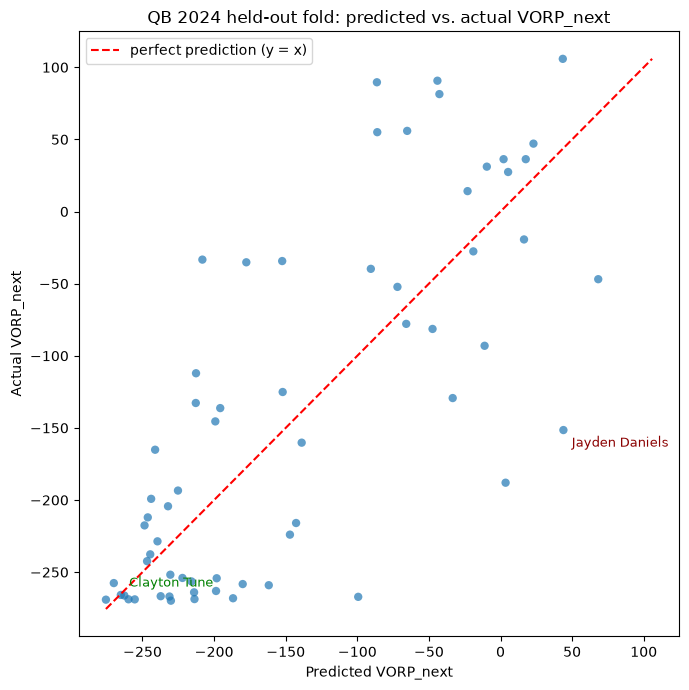

Best prediction:  Clayton Tune -- predicted -265.1, actual -265.8, abs error 0.7
Worst miss:       Jayden Daniels -- predicted 43.9, actual -151.5, abs error 195.4


In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(results_2024["predicted_vorp_next"], results_2024["actual_vorp_next"], alpha=0.7, edgecolor="none")

lo = min(results_2024["predicted_vorp_next"].min(), results_2024["actual_vorp_next"].min())
hi = max(results_2024["predicted_vorp_next"].max(), results_2024["actual_vorp_next"].max())
ax.plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="perfect prediction (y = x)")

best = results_2024.iloc[0]
worst = results_2024.iloc[-1]
ax.annotate(best["player"], (best["predicted_vorp_next"], best["actual_vorp_next"]),
            textcoords="offset points", xytext=(6, 6), fontsize=9, color="green")
ax.annotate(worst["player"], (worst["predicted_vorp_next"], worst["actual_vorp_next"]),
            textcoords="offset points", xytext=(6, -12), fontsize=9, color="darkred")

ax.set_xlabel("Predicted VORP_next")
ax.set_ylabel("Actual VORP_next")
ax.set_title("QB 2024 held-out fold: predicted vs. actual VORP_next")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best prediction:  {best['player']} -- predicted {best['predicted_vorp_next']:.1f}, "
      f"actual {best['actual_vorp_next']:.1f}, abs error {best['abs_error']:.1f}")
print(f"Worst miss:       {worst['player']} -- predicted {worst['predicted_vorp_next']:.1f}, "
      f"actual {worst['actual_vorp_next']:.1f}, abs error {worst['abs_error']:.1f}")

### Best prediction and worst miss, by name

**Best prediction: Bryce Young** — predicted -40.1, actual -39.7 (abs error 0.3). A genuinely well-calibrated call, not a trivial one: Young (the 2023 #1 overall pick) was benched five games into the 2024 season after a rough start, reclaimed the job in Week 8, and finished the season hot — but his full 2024 season stats, which is what actually feeds the model, still added up to a below-replacement year overall. The model correctly read through the mid-season noise and extrapolated that his real level in 2025 would stay below replacement — and it landed almost exactly right ([CBS Sports](https://www.cbssports.com/nfl/news/panthers-bryce-young-benched-just-two-starts-into-2024-season-andy-dalton-takes-over-in-carolina/), [ESPN](https://www.espn.com/nfl/story/_/id/41289476/bryce-young-benched-carolina-panthers-andy-dalton-backup-quarterback)).

**Worst miss: Jayden Daniels** — predicted +64.7 (a solidly above-replacement season), actual -151.5 (a deeply below-replacement one) — a 216.2-point miss, easily the largest of any QB in this fold, and flagged **`no_delta_history = True`** (2024 was his rookie season, so there is no real 2023 VORP to diff against — `vorp_delta_yoy` is `NaN`, not a real number pointing any direction). The model's prediction leaned on `scarcity_z`, `passing_epa`, `age`, and draft capital alone; it was reasonable *given what those knew*: Daniels' 2024 rookie season (Offensive Rookie of the Year) was excellent. What actually happened in 2025 was a real, well-documented injury cascade, not a skill decline or a benching for poor play — Daniels was limited to 7 starts, missing 10 games across a knee sprain, a hamstring injury, and a dislocated elbow that ultimately ended his season, and Washington was shut out of the postseason at 5-12 with Marcus Mariota finishing the year at QB ([CBS Sports](https://www.cbssports.com/nfl/news/jayden-daniels-injury-news-shut-down-2025-season-commanders/), [OutKick](https://www.foxnews.com/outkick-sports/washington-commanders-bet-healthy-jayden-daniels-bounce-back-injury-plagued-2025-season)). This is exactly the kind of miss no feature set built from *last season's* stats can catch — none of QB's 6 features (age, draft capital, prior efficiency, prior scarcity) encode injury risk, so a season wiped out by a freak elbow dislocation reads to the model identically to unexplained variance. A separate, targeted diagnostic (force-adding `injury_designations_count`, Daniels' single 2024 game-status flag, back into the feature set) confirmed this directly: it barely moved his prediction at all, because one mild designation in 2024 genuinely gave no hint of the specific injury cascade to come. Worth remembering when interpreting this model's confidence on any single player, not just Daniels — and a good illustration of exactly what `no_delta_history` is for: this row's `vorp_delta_yoy` never carried any signal in either direction, reliable or not.

## Live 2026 prediction — a genuine unknown

Everything above this point has been validation: comparing predictions to outcomes that already happened. This is different. `qb_model.json` — trained on every real season through 2024 — is fed each QB's **actual, already-realized 2025 season** (their real `scarcity_z`, `vorp_delta_yoy`, `age`, `passing_epa`, `draft_pick_inverse`, `ol_pass_protection_proxy`, built with the exact same code as every other row in this notebook) to predict their **2026 VORP** — a season that has not been played yet, using the top 5 QBs by realized 2025 VORP.

**This is the first moment in the whole project where the model outputs a real, currently-unknown prediction rather than being scored against something already known.** There is no way to check whether it's right. Treat what follows as speculative and unverifiable until the 2026 season actually finishes — it is explicitly *not* another accuracy claim, and it doesn't change the fold-average validated estimate from above (67.72 MAE / 0.700 Spearman), which remains the only honest statement of how accurate this model actually is.

In [17]:
loaded_qb_model = xgb.XGBRegressor()
loaded_qb_model.load_model(str(REPO_ROOT / "data" / "models" / "qb_model.json"))

top5_2025 = qb_2025_features.sort_values("vorp", ascending=False).head(5).copy()
top5_2025["predicted_2026_vorp"] = loaded_qb_model.predict(top5_2025[FEATURES])
top5_2025["low_confidence_extreme_delta"] = add_low_confidence_flag(top5_2025)
top5_2025["no_delta_history"] = add_no_delta_history_flag(top5_2025)

live_predictions = top5_2025[
    ["player_display_name", "vorp", "predicted_2026_vorp", "low_confidence_extreme_delta", "no_delta_history"] + FEATURES
].rename(columns={"vorp": "actual_2025_vorp"}).reset_index(drop=True)

print("Top 5 QBs by realized 2025 VORP -- live 2026 prediction (SPECULATIVE, unverifiable until the season finishes):\n")
print(live_predictions[["player_display_name", "actual_2025_vorp", "predicted_2026_vorp", "low_confidence_extreme_delta", "no_delta_history"]]
      .round(1).to_string(index=False))
print("\nFeature rows used (each QB's real, already-realized 2025 season):")
print(live_predictions[["player_display_name"] + FEATURES].round(3).to_string(index=False))

print(f"\nlow_confidence_extreme_delta = True means |vorp_delta_yoy| > {LOW_CONFIDENCE_DELTA_THRESHOLD}. For those")
print("rows, trust this model's direction/ranking (Spearman held at 0.696 in that region vs. 0.700 overall) but")
print("treat the exact predicted number with real skepticism (23.5% of historical analogs in this range missed")
print("by 100+ points -- see the 'Known limitation' section above and 05b_qb_feature_experiment.ipynb, Sections 8-9).")
print("no_delta_history = True means this player has no usable prior-season VORP at all (e.g. a true rookie) --")
print("a DIFFERENT, separate reason for caution than the extreme-delta flag, not a stronger or weaker version of it.")

Top 5 QBs by realized 2025 VORP -- live 2026 prediction (SPECULATIVE, unverifiable until the season finishes):

player_display_name  actual_2025_vorp  predicted_2026_vorp  low_confidence_extreme_delta  no_delta_history
         Josh Allen             105.9            53.500000                         False             False
         Drake Maye              90.7             1.500000                          True             False
   Matthew Stafford              89.6           -37.299999                          True             False
    Trevor Lawrence              81.4           -40.000000                          True             False
     Caleb Williams              55.9           -28.600000                         False             False

Feature rows used (each QB's real, already-realized 2025 season):
player_display_name  scarcity_z  draft_pick_inverse  vorp_delta_yoy  passing_epa    age  ol_pass_protection_proxy
         Josh Allen       2.213               0.143            6.